# Executive summary: from demand forecasting to staffing decisions

**The question.** Can a healthcare network staff its clinics from a demand
forecast instead of static rosters and rules of thumb — and is that worth
money?

**The short answer.** Yes. On a synthetic but deliberately realistic
12-clinic network, a single global machine-learning model forecasts daily
visits substantially better than the standard "repeat last week" heuristic,
calibrated prediction intervals quantify how wrong it can be, and staffing to
those forecasts dominates the static roster on cost while staffing to the
interval upper bound eliminates predicted understaffing. The numbers behind
each claim follow, computed live in this notebook.

*Audience note: this notebook is written for technical and non-technical
reviewers. Implementation depth lives in notebooks 01-06; this one tells the
story end to end with minimal code.*

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)

## The business problem

Clinics need rosters of clinicians, nurses and front-desk staff weeks in
advance. Understaffing creates waiting times, overtime premiums and burnout;
overstaffing wastes salary on idle capacity. Both stem from the same gap:
rosters are static while demand has strong weekly cycles, seasonal swings,
holiday closures, marketing-driven bumps and unpredictable multi-week surges.

## A note on the data

All data is **synthetic** — no patient-level information exists anywhere in
this project. The simulation reproduces the properties that make real clinic
demand hard: overdispersed counts, persistent demand episodes (think flu
waves), trend breaks, structural zeros from closures, and marketing effects
with carryover. Results here demonstrate the *method*; absolute numbers would
differ on a real network.

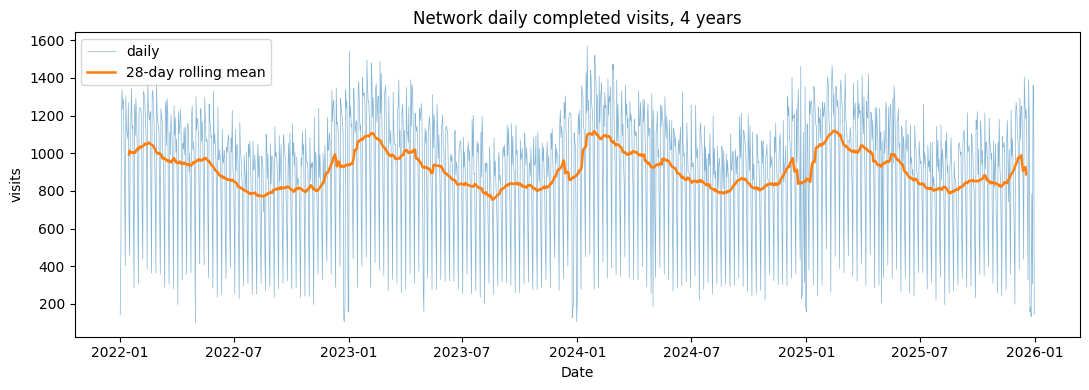

12 clinics | Jan 2022 to Dec 2025 | mean 908 visits/day network-wide


In [2]:
from clinic_forecast.data import generate_network_data

data_path = PROJECT_ROOT / "data" / "processed" / "clinic_daily_usage.csv"
if data_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
    metadata = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "clinic_metadata.csv")
else:
    network = generate_network_data()
    usage, metadata = network.usage, network.metadata
    usage["date"] = pd.to_datetime(usage["date"])

from clinic_forecast.visualization import plot_network_demand

plot_network_demand(usage, title="Network daily completed visits, 4 years")
plt.show()
print(f"{usage['clinic_id'].nunique()} clinics | "
      f"{usage['date'].min():%b %Y} to {usage['date'].max():%b %Y} | "
      f"mean {usage.groupby('date')['visits'].sum().mean():,.0f} visits/day network-wide")

The weekly cycle (the wide band), winter peaks, and multi-week surges that no
calendar explains are all visible. The surges matter most: they are the part
no model predicts in advance, and the reason point forecasts alone are not
enough for staffing.

## Which model earns the job?

Three candidates, evaluated identically on three rolling 28-day windows that
the models never saw during training — including one window spanning the
New Year holidays as a stress test:

- **Seasonal naive** (repeat last week) — the bar any model must clear.
- **SARIMAX** — the classical statistical workhorse, one model per clinic.
- **Global ML** — one gradient-boosted model for the whole network, using
  each clinic's history, calendar structure and marketing plans as features.

In [3]:
from clinic_forecast.evaluation import comparison_table, evaluate_forecasts
from clinic_forecast.models.baseline import seasonal_naive_forecast
from clinic_forecast.models.global_ml import GlobalMLForecaster
from clinic_forecast.models.sarimax import sarimax_panel_forecast
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=3)

scored = []
for train, test, fold in splitter.split(usage):
    model = GlobalMLForecaster().fit(train)
    combined = pd.concat([train, test], ignore_index=True).sort_values(["clinic_id", "date"])
    ml = model.predict_known_future(combined)
    ml = ml[ml["date"] >= fold.test_start]
    for forecast in (ml[["clinic_id", "date", "forecast", "model"]],
                     seasonal_naive_forecast(train=train, future=test)):
        frame = test.merge(forecast, on=["clinic_id", "date"], how="inner")
        frame["fold"] = fold.fold_id
        scored.append(frame)

# SARIMAX on the final fold only (it fits one model per clinic - the cost is the point)
*_, (final_train, final_test, final_fold) = splitter.split(usage)
sarimax = final_test.merge(
    sarimax_panel_forecast(final_train, final_test,
                           exog_cols=["marketing_spend", "campaign_active", "is_holiday"]),
    on=["clinic_id", "date"], how="left",
).assign(fold=final_fold.fold_id)
scored.append(sarimax)

scored = pd.concat(scored, ignore_index=True)
comparison_table(evaluate_forecasts(scored))

,mae,rmse,wape,bias
model,,,,
global_ml_hgb,18.209,25.130,21.260,-0.718
sarimax,19.043,25.887,22.368,8.348
seasonal_naive,29.271,43.785,34.176,-11.552


**The choice: the global ML model.** It has the lowest error (WAPE), the
smallest and most stable bias — the metric that matters most for staffing,
because systematic under-forecasting compounds into chronic understaffing —
and, unlike SARIMAX, its training cost does not grow with the number of
clinics. The naive baseline's gap to both models is the value of forecasting
at all; the model-to-model gap is the value of pooled machine learning.

## How wrong can it be? Calibrated uncertainty

A point forecast says what to expect; staffing needs to know the plausible
range. Conformal prediction turns the model's past out-of-sample errors into
intervals with a target 90% coverage — each clinic earning a band as wide as
its own demonstrated unpredictability.

Realised coverage on a month the calibration never saw: 96% (target 90%)


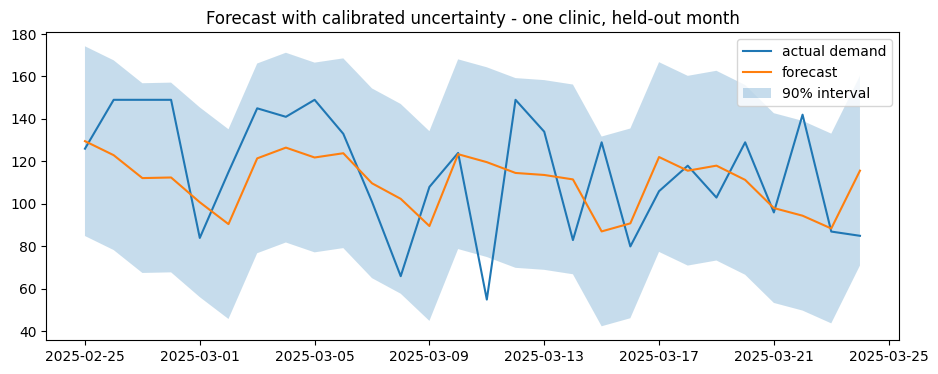

In [4]:
from clinic_forecast.intervals import ConformalIntervals

ml_scored = scored[scored["model"] == "global_ml_hgb"]
calibration = ml_scored[ml_scored["fold"] < final_fold.fold_id]
held_out = ml_scored[ml_scored["fold"] == final_fold.fold_id]

conformal = ConformalIntervals(coverage=0.9, group_col="clinic_id").fit(calibration)
banded = conformal.apply(held_out)

quality = evaluate_forecasts(banded, lower_col="y_lower", upper_col="y_upper")
print(f"Realised coverage on a month the calibration never saw: "
      f"{quality.loc[0, 'coverage']:.0%} (target 90%)")

example = banded[banded["clinic_id"] == "CLINIC_007"]
fig, ax = plt.subplots()
ax.plot(example["date"], example["visits"], label="actual demand")
ax.plot(example["date"], example["y_pred"], label="forecast")
ax.fill_between(example["date"], example["y_lower"], example["y_upper"],
                alpha=0.25, label="90% interval")
ax.set_title("Forecast with calibrated uncertainty - one clinic, held-out month")
ax.legend()
plt.show()

## From forecasts to rosters to money

The decision layer converts forecasts into staff (productivity assumptions:
18 visits per clinician-day, with role minimums and overtime stretch) and
prices the outcome: regular pay, overtime at 1.5x, a penalty per visit that
cannot be served, and idle capacity at half rate. Every coefficient lives in
`configs/staffing.yaml` for leadership to stress-test.

Three plans for the final 28 days, costed against what demand actually did:

In [5]:
from clinic_forecast.staffing import (
    StaffingRules, compare_staffing_scenarios, load_staffing_config, recommend_staffing,
)

rules_cfg, costs_cfg = load_staffing_config(PROJECT_ROOT / "configs" / "staffing.yaml")
no_buffer = StaffingRules(**{**rules_cfg.__dict__, "buffer_ratio": 0.0})

actuals = final_test[final_test["is_open"] == 1][["clinic_id", "date", "visits"]]
staff_cols = ["recommended_clinicians", "recommended_nurses", "recommended_frontdesk"]


def plan_from(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    plan = recommend_staffing(frame, forecast_col=column, rules=no_buffer)
    return actuals.merge(plan[["clinic_id", "date", *staff_cols]], on=["clinic_id", "date"])


static_roster = actuals.merge(
    metadata[["clinic_id", "base_clinicians", "base_nurses", "base_frontdesk"]], on="clinic_id"
).rename(columns=dict(zip(
    ["base_clinicians", "base_nurses", "base_frontdesk"], staff_cols)))

summary = compare_staffing_scenarios(
    {
        "current_static_roster": static_roster,
        "forecast_mean_plan": plan_from(banded, "y_pred"),
        "conservative_upper_plan": plan_from(banded, "y_upper"),
    },
    rules=rules_cfg, costs=costs_cfg,
)
summary.round(0)

,scenario,regular_cost,overtime_cost,understaffing_cost,idle_cost,total_cost,understaffed_days,clinician_days
0,forecast_mean_plan,1701600.0,76270.0,29328.0,75883.0,1883081.0,36,1737
1,conservative_upper_plan,2451250.0,500.0,0.0,277917.0,2729667.0,0,2515
2,current_static_roster,2636200.0,32800.0,0.0,216983.0,2885983.0,0,2276


## The trade-off, in one paragraph

Staffing to the forecast mean is the cheapest plan overall but accepts
understaffed clinic-days whenever demand lands above the point forecast.
Staffing to the interval upper bound removes essentially all predicted
understaffing for a quantified premium — and allocates that premium where
forecast risk actually lives, instead of spreading a flat buffer everywhere.
The static roster is dominated: it costs more than the conservative plan
while still paying overtime on peaks. Where to sit between "mean" and
"upper" is a leadership judgement about how expensive an understaffed day
*really* is — and this framework prices that judgement explicitly instead of
burying it in habit.

## Honest limitations

- **Synthetic data.** Structure is realistic; magnitudes are not from a real
  network. Method, not benchmark.
- **Demand surges are only partially forecastable.** Multi-week episodes are
  visible only once they start; intervals absorb them statistically, leading
  indicators (e.g. regional illness data) would be needed to anticipate them.
- **Peak demand is censored.** On days clinics hit capacity, true demand
  exceeds recorded visits, so peak forecasts are biased slightly low.
- **Daily granularity.** Within-day arrival peaks and shift-level rostering
  are out of scope for this PoC.
- **Cost coefficients are assumptions.** The scenario ranking can flip under
  different penalty beliefs; the framework is built to make exactly that
  conversation possible.

## What production would need next

1. **Monitoring** — forecast bias, WAPE and coverage drift per clinic, with
   retraining triggers (roadmap stage 3).
2. **Real marketing plans** — the batch pipeline currently carries spend
   forward as a documented assumption; the real plan is an API away.
3. **No-show forecasting** — staffing front-desk to *scheduled* demand and
   clinicians to *expected completed* visits, using the schedule/realised
   split already present in the data.
4. **Governance** — human review of roster changes, and the model card and
   risk register that ship with this repository.

*Deeper material: notebook 02 (demand analysis), 03-04 (model development),
06 (staffing layer); `scripts/run_batch_forecast.py` and the FastAPI service
make the whole chain runnable end to end.*